# 3. Example: 4DVar Backprop DA using Reservoir Computing ML Model on QGS Model - RayTune for HyperParams

Using Reservoir Computing model macro-parameters from QGS/Jason Platt's paper: Platt, J. A., Wong, A., Clark, R., Penny, S. G. & Abarbanel, H. D. I. Robust forecasting using predictive generalized synchronization in reservoir computing. Chaos: An Interdisciplinary Journal of Nonlinear Science 31, 123118 (2021).


In [1]:
import dabench as dab
import numpy as np
import matplotlib.pyplot as plt
from qgs.params.params import QgParams
import pandas as pd
import os
import jax.numpy as jnp

from ray import train, tune
from hyperopt import hp
from ray.tune.search.hyperopt import HyperOptSearch

In [2]:
%%bash
# Make output dir
mkdir -p out_rev/qgs

In [ ]:
random_seed=55
np_rng = np.random.default_rng(seed=random_seed)

In [4]:
ensemble_size = 250

## A. Create Nature Run

In [5]:
# Time parameters
dt = 0.5
# transient time to attractor
transient_time = 1.e5
# integration time on the attractor
integration_time = 1.e4


# Setting some model parameters
# Model parameters instantiation with some non-default specs
model_params = QgParams({'phi0_npi': np.deg2rad(50.)/np.pi, 'hd': 0.1})
# Mode truncation at the wavenumber 2 in both x and y spatial coordinate
model_params.set_atmospheric_channel_fourier_modes(2, 2)

# Changing (increasing) the orography depth and the meridional temperature gradient
model_params.ground_params.set_orography(0.2, 1)
model_params.atemperature_params.set_thetas(0.2, 0)

In [6]:
train_size = 100000
cov_size = 10000

In [7]:
nature_run = dab.data.QGS(model_params=model_params, store_as_jax=False, delta_t=dt,
                          random_seed=random_seed)
nature_run.generate(n_steps=200*1000, stride=1000, x0=np_rng.random(model_params.ndim)*0.001, mxstep=5000)
x0 = nature_run.values[-1]

In [8]:
nature_run.generate(x0=x0, n_steps=(train_size + cov_size), mxstep=5000)

In [9]:
# NOTE: This raises a Parameter dimensional conversion warning that can be safely ignored
nr_train, nr_cov, _ = nature_run.split_train_valid_test(
    train_size, cov_size, 0)

/home/ksolvik/miniconda3/envs/dab-old/lib/python3.11/site-packages/qgs/params/parameter.py:106: UserWarning: Parameter configured to perform dimensional conversion but without specifying a ScaleParams object: Conversion disabled!
  warnings.warn("Parameter configured to perform dimensional conversion " +


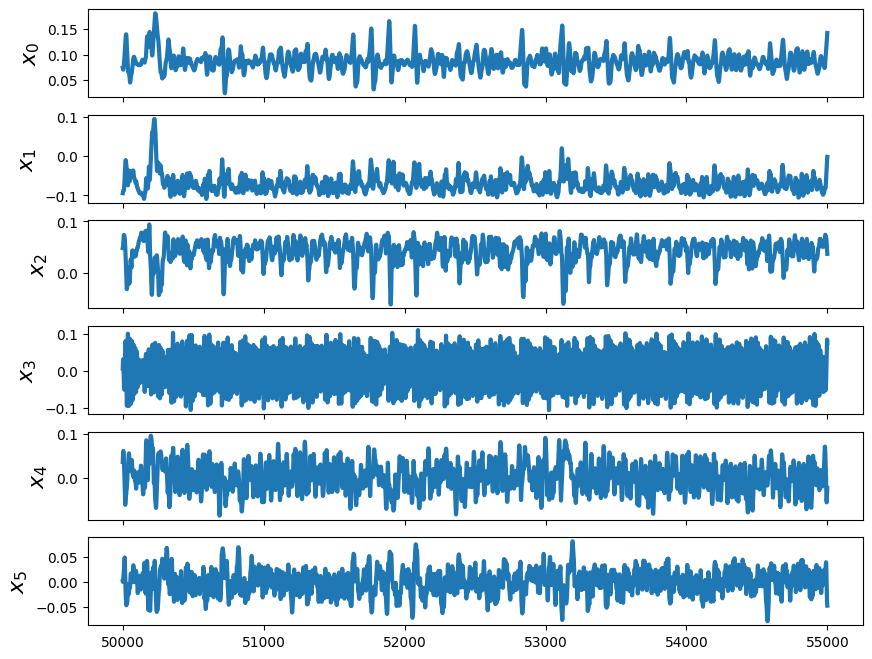

In [10]:
# Let's visualize the results
fig, axes = plt.subplots(6, 1, sharex = True, figsize = (10, 8))
for j, ax in enumerate(axes):
    ax.plot(nr_cov.times, nr_cov.values[:,j], lw = 3, label = 'Nature Run')
    ax.set_ylabel(r'$x_{:d}$'.format(j), fontsize = 16)

## B. Generate Observations

In [11]:
# First we need to calculate the per-variable SD for QGS model
obs_sd_scale = 0.1
per_variable_sd = np.std(nr_train.values, axis=0)
obs_sd = 0.1*per_variable_sd

In [12]:
# Now we can define the observer:
obs_qgs_cov = dab.observer.Observer(
    nr_cov, # Data generator object
    time_indices = np.arange(0, nr_cov.time_dim, 3), # Observation every 5th timestep
    random_location_count = 10,
    error_bias = 0.0, 
    error_sd = obs_sd,  
    random_seed=93,
    stationary_observers=True,
    store_as_jax=False
)

# Making observations
obs_vec_cov = obs_qgs_cov.observe()

## C. Define and train model

In [13]:
# Define model
forecast_model = dab.model.RCModel(
    system_dim=20, 
    reservoir_dim=2000, 
    input_dim=20, 
    sparse_adj_matrix=False, 
    sparsity=0.99,
    readout_method='linear',
    sigma=0.98765777241154,
    sigma_bias = 0.675882947305197,
    spectral_radius =  0.376752115791648, # SR 
    leak_rate=0.5343730100231164, # alpha
    log_beta=-20.219432227197363)

In [ ]:
# Checks for presaved weights. If not present, trains RC model and saves weights
weights_path = './out_rev/qgs/rc_weights.pkl'
if os.path.isfile(weights_path):
    # Shortcut: Load previously trained weights
    forecast_model.weights_init()
    forecast_model.load_weights(weights_path)
else:
    # Train: Takes ~5 minutes
    forecast_model.weights_init()
    forecast_model.train(nr_train)
    forecast_model.save_weights(weights_path)

## D. Set up and run DA Cycler for validation period

In [15]:
# Getting standard deviation of reservoir state values for sigma_bg
train_res_sd = np.std(forecast_model.generate(nr_train.values), axis=0)

In [16]:
obs_times_per_window=3
obs_location_count = obs_vec_cov.location_indices.shape[1]
sigma_obs=obs_sd[obs_vec_cov.location_indices[0]]*1.25
sigma_bg = 0.1*train_res_sd 

total_obs_count = obs_times_per_window*obs_location_count
R = (np.tile(sigma_obs, obs_times_per_window)**2)* np.identity(total_obs_count)
# R = (sigma_obs**2)*np.identity(sigma_obs.shape[0])
B = (sigma_bg**2)*np.identity(forecast_model.reservoir_dim)
S = np.zeros((total_obs_count, 20))
S[np.arange(S.shape[0]), np.tile(obs_vec_cov.location_indices[0], obs_times_per_window)] = 1
H = S @ forecast_model.Wout.T

In [17]:
r0_original = jnp.stack([forecast_model.update(forecast_model.generate(
        nr_train.values[-100:]
        + np.random.normal(size = (100, nr_train.system_dim), scale=obs_sd))[-1], nr_train.values[-1])
        for i in range(ensemble_size)])
r0_sv = dab.vector.StateVector(
    values=r0_original,
    store_as_jax=True)

In [18]:

dc = dab.dacycler.ETKF(
    system_dim=forecast_model.reservoir_dim,
    delta_t=nr_cov.delta_t,
    H=H,
    B=B,
    R=R,
    model_obj=forecast_model,
    steps_per_window=10, # 10 instead of 9 because inclusive of start and end
    ensemble_dim=ensemble_size,
    multiplicative_inflation=1.02
)
cur_tstep = 0

out_statevec= dc.cycle(
    input_state = r0_sv,
    start_time = nr_cov.times[cur_tstep],
    obs_vector = obs_vec_cov,
    analysis_window=4.5,
    n_cycles=200, #int(nr_cov.time_dim/9)-2,
    obs_error_sd=sigma_obs,
    return_forecast=True)

analyses_stacked = forecast_model.readout(out_statevec.values)

np.save('./out_rev/qgs/qgs_rc_etkf_v2.pkl', analyses_stacked)

2024-11-14 07:47:31.813254: E external/xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module jit_scan] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2024-11-14 07:48:06.875400: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m35.062269048s

********************************
[Compiling module jit_scan] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


In [19]:

# np.save('./out_rev/qgs/qgs_rc_etkf_v1.pkl', analyses_stacked)

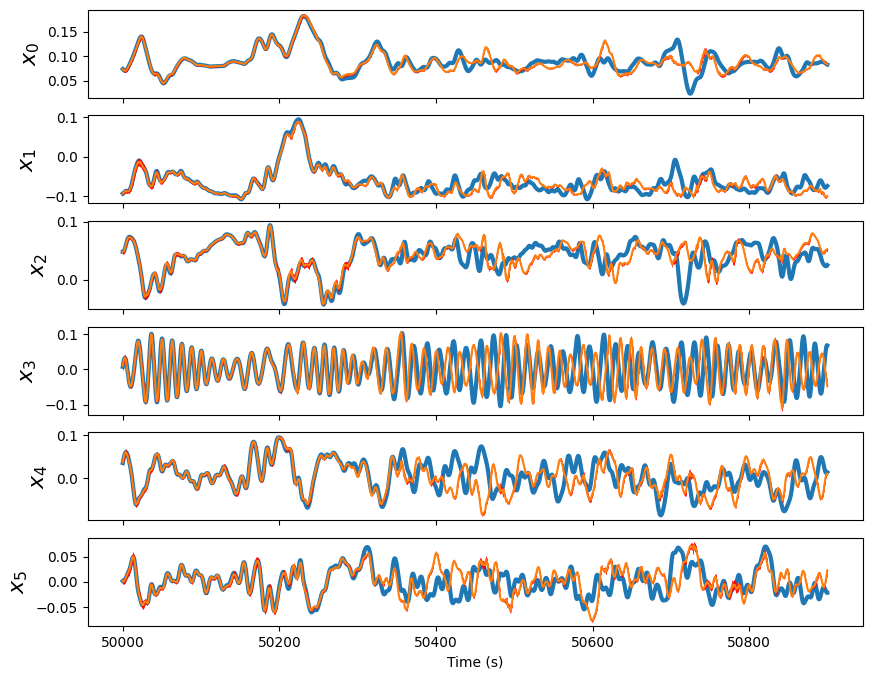

In [20]:
fig, axes = plt.subplots(6, 1, sharex = True, figsize = (10, 8))
for j, ax in enumerate(axes):
    ax.plot(out_statevec.times, nr_cov.values[:out_statevec.times.shape[0],j], lw = 3, label = 'True')
    ax.errorbar(out_statevec.times, np.mean(analyses_stacked, axis=1)[:,j],
                yerr=np.ptp(analyses_stacked, axis=1)[:,j], elinewidth=0.5, ecolor='red')
    ax.set_ylabel(r'$x_{:d}$'.format(j), fontsize = 16)
ax.set_xlabel('Time (s)')
plt.show()